# EDA de Matriculados UNSTA

Este notebook realiza un **análisis exploratorio** de los snapshots exportados a MinIO:
- `vw_dm_matricula_total`
- `vw_dm_matricula_carrera`

**Objetivos:**
- Entender estructura y calidad de los datos.
- Revisar patrones temporales (año/cuatrimestre).
- Preparar insumos para la comparación de modelos baseline vs series temporales.

## Instalación de dependencias

**Ejecutá esta celda una sola vez** (la primera vez que abras el notebook o al cambiar de entorno). Luego reiniciá el kernel y ejecutá el resto de celdas.

In [ ]:
# Instalar todas las librerías necesarias para este notebook (y dataset.ipynb).
# Ejecutar una vez; después: Kernel -> Restart y correr el resto.
%pip install pandas sqlalchemy pymysql boto3 numpy matplotlib seaborn --quiet

In [24]:
# Descripcion:
# Esta celda importa librerias, configura estilo visual y define variables de entorno
# para conectarse a MinIO/S3 y al bucket donde estan los snapshots.
import os
import re
from io import BytesIO

import boto3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Configuracion MinIO / S3 compatible
os.environ.setdefault("AWS_ACCESS_KEY_ID", "minio")
os.environ.setdefault("AWS_SECRET_ACCESS_KEY", "minio123")
os.environ.setdefault("AWS_ENDPOINT_URL_S3", "http://localhost:9000")

BUCKET = os.getenv("DATA_REPO_BUCKET_NAME", "data")
BASE_PREFIX = "mysql_exports/unsta"

print("AWS_ENDPOINT_URL_S3:", os.environ.get("AWS_ENDPOINT_URL_S3"))
print("BUCKET:", BUCKET)

AWS_ENDPOINT_URL_S3: http://localhost:9000
BUCKET: data


In [26]:
# Descripcion:
# Esta celda define funciones auxiliares para listar snapshots, elegir el mas reciente,
# leer CSV desde MinIO y cargar los dos datasets principales (total y carrera).
SNAPSHOT_REGEX = re.compile(r"snapshot_(\d{8}T\d{6})\.csv$")


def get_s3_client():
    return boto3.client(
        "s3",
        endpoint_url=os.getenv("AWS_ENDPOINT_URL_S3"),
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    )


def list_snapshot_keys(s3_client, bucket: str, prefix: str):
    keys = []
    token = None
    while True:
        kwargs = {"Bucket": bucket, "Prefix": prefix}
        if token:
            kwargs["ContinuationToken"] = token
        response = s3_client.list_objects_v2(**kwargs)
        for obj in response.get("Contents", []):
            key = obj["Key"]
            if SNAPSHOT_REGEX.search(key):
                keys.append(key)
        if not response.get("IsTruncated"):
            break
        token = response.get("NextContinuationToken")
    return sorted(keys)


def latest_snapshot_key(keys):
    if not keys:
        raise ValueError("No se encontraron snapshots para el prefijo indicado.")
    return sorted(keys, key=lambda k: SNAPSHOT_REGEX.search(k).group(1))[-1]


def read_csv_from_s3(s3_client, bucket: str, key: str) -> pd.DataFrame:
    obj = s3_client.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(BytesIO(obj["Body"].read()))


s3 = get_s3_client()

key_total = latest_snapshot_key(
    list_snapshot_keys(s3, BUCKET, f"{BASE_PREFIX}/vw_dm_matricula_total/")
)
key_carrera = latest_snapshot_key(
    list_snapshot_keys(s3, BUCKET, f"{BASE_PREFIX}/vw_dm_matricula_carrera/")
)

print("Snapshot total:", key_total)
print("Snapshot carrera:", key_carrera)

df_total = read_csv_from_s3(s3, BUCKET, key_total)
df_carrera = read_csv_from_s3(s3, BUCKET, key_carrera)

df_total.columns = [c.strip().lower() for c in df_total.columns]
df_carrera.columns = [c.strip().lower() for c in df_carrera.columns]

# Etiquetas legibles para carrera (nombre_carrera o abreviatura_carrera si la vista las trae)
id_col_carrera = "id_carrera" if "id_carrera" in df_carrera.columns else "carrera_id"
tmp = df_carrera.drop_duplicates(subset=[id_col_carrera]).copy()

def _pick_label(r):
    if "nombre_carrera" in r.index and pd.notna(r.get("nombre_carrera")) and str(r["nombre_carrera"]).strip():
        return str(r["nombre_carrera"]).strip()
    if "abreviatura_carrera" in r.index and pd.notna(r.get("abreviatura_carrera")) and str(r["abreviatura_carrera"]).strip():
        return str(r["abreviatura_carrera"]).strip()
    return r[id_col_carrera]

carrera_etiquetas = tmp.set_index(id_col_carrera).apply(_pick_label, axis=1)

print("df_total shape:", df_total.shape)
print("df_carrera shape:", df_carrera.shape)


Snapshot total: mysql_exports/unsta/vw_dm_matricula_total/snapshot_20260306T030000.csv
Snapshot carrera: mysql_exports/unsta/vw_dm_matricula_carrera/snapshot_20260306T030000.csv


KeyError: 'id_carrera'

## 1. Inspección inicial de los datos

### 1.1 Estructura de los datasets

Se trabaja con dos datasets que provienen de snapshots CSV almacenados en MinIO:

| Dataset | Granularidad | Variable objetivo | Uso en el proyecto |
|---|---|---|---|
| `vw_dm_matricula_total` | año + cuatrimestre | `matriculados_objetivo` | Modelo de predicción global (nivel universidad) |
| `vw_dm_matricula_carrera` | año + cuatrimestre + carrera | `matriculados_carrera` | Modelo de predicción por carrera |

### 1.2 Calidad de los datos

Antes de realizar cualquier análisis se verifica la ausencia de valores nulos y duplicados exactos. La integridad de los datos en este punto es esperable dado que provienen de vistas SQL que ya aplican deduplicación y filtros de rango temporal.

In [15]:
# Descripcion:
# Esta celda muestra una primera inspeccion: nombres de columnas y primeras filas
# para entender la estructura general de ambos datasets.
# Vista rapida de datos
print("Columnas total:", list(df_total.columns))
print("Columnas carrera:", list(df_carrera.columns))

display(df_total.head())
display(df_carrera.head())

Columnas total: ['anio', 'cuatrimestre', 'aspirantes_total', 'aspirantes_con_id_alumno', 'matriculados_objetivo']
Columnas carrera: ['anio', 'cuatrimestre', 'id_carrera', 'matriculados_carrera']


,anio,cuatrimestre,aspirantes_total,aspirantes_con_id_alumno,matriculados_objetivo
0,2007,1,2074,1,1
1,2007,2,246,0,0
2,2008,1,1900,0,0
3,2008,2,154,0,0
4,2009,1,1752,0,0


,anio,cuatrimestre,id_carrera,matriculados_carrera
0,2007,1,29,1
1,2013,1,18,1
2,2013,1,49,4
3,2013,2,12,1
4,2014,1,01,43


In [16]:
# Descripcion:
# Esta celda evalua calidad de datos en cada tabla: cantidad de nulos,
# filas duplicadas y dimension general.
# Calidad de datos: nulos y duplicados

def data_quality_report(df: pd.DataFrame, name: str):
    nulls = df.isna().sum().sort_values(ascending=False)
    nulls = nulls[nulls > 0]
    print(f"\n===== {name} =====")
    print("Filas:", len(df), "| Columnas:", len(df.columns))
    print("Duplicados exactos:", df.duplicated().sum())
    if len(nulls) == 0:
        print("Sin nulos.")
    else:
        display(nulls.to_frame("null_count"))


data_quality_report(df_total, "TOTAL")
data_quality_report(df_carrera, "CARRERA")


===== TOTAL =====
Filas: 38 | Columnas: 5
Duplicados exactos: 0
Sin nulos.

===== CARRERA =====
Filas: 1011 | Columnas: 4
Duplicados exactos: 0
Sin nulos.


In [17]:
# Descripcion:
# Esta celda construye utilidades para:
# 1) inferir la columna objetivo de matriculados,
# 2) crear el eje temporal (anio + cuatrimestre),
# 3) dejar listas las variables para analisis/modelado.
# Utilidades para preparar eje temporal y detectar columna objetivo

def infer_target_col(df: pd.DataFrame, excluded: set[str]):
    preferred = [
        "matriculados", "total_matriculados", "cantidad_matriculados", "n_matriculados", "cantidad", "total"
    ]
    for c in preferred:
        if c in df.columns and c not in excluded:
            return c

    candidates = [
        c for c in df.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(df[c])
    ]
    if not candidates:
        raise ValueError("No se pudo inferir columna objetivo.")
    return candidates[0]


def build_time_order(df: pd.DataFrame):
    year_col = next((c for c in ["periodo", "anio", "year"] if c in df.columns), None)
    term_col = next((c for c in ["id_cuatrimestre", "cuatrimestre", "term", "semester"] if c in df.columns), None)
    if year_col is None:
        raise ValueError("No se encontro columna de anio (periodo/anio/year).")

    out = df.copy()
    out[year_col] = pd.to_numeric(out[year_col], errors="coerce")
    out = out.dropna(subset=[year_col])
    out[year_col] = out[year_col].astype(int)

    if term_col is not None:
        out[term_col] = pd.to_numeric(out[term_col], errors="coerce").fillna(0).astype(int)
        out["time_order"] = out[year_col] * 10 + out[term_col]
        out["period_label"] = out[year_col].astype(str) + "-" + out[term_col].astype(str)
    else:
        out["time_order"] = out[year_col]
        out["period_label"] = out[year_col].astype(str)

    return out, year_col, term_col


df_total_t, ycol_total, tcol_total = build_time_order(df_total)
df_carrera_t, ycol_carrera, tcol_carrera = build_time_order(df_carrera)

career_col = "id_carrera" if "id_carrera" in df_carrera_t.columns else "carrera_id"

target_total = infer_target_col(df_total_t, excluded={ycol_total, tcol_total, "time_order"})
target_carrera = infer_target_col(df_carrera_t, excluded={ycol_carrera, tcol_carrera, "time_order", "id_carrera", "carrera_id"})

print("Target total:", target_total)
print("Target carrera:", target_carrera)
print("Year col total/carrera:", ycol_total, ycol_carrera)
print("Term col total/carrera:", tcol_total, tcol_carrera)

Target total: aspirantes_total
Target carrera: matriculados_carrera
Year col total/carrera: anio anio
Term col total/carrera: cuatrimestre cuatrimestre


## 2. Evolución temporal — Serie total universidad

### 2.1 ¿Qué estamos visualizando?

La **serie temporal de matriculados a nivel universidad** es la variable objetivo del modelo de predicción global. Cada punto del gráfico representa la cantidad de alumnos que efectivamente se matricularon en un período dado (año + cuatrimestre).

Al observarla visualmente buscamos identificar:

- **Tendencia**: ¿la matrícula crece, decrece o se mantiene estable a lo largo de los años?
- **Estacionalidad**: ¿hay diferencias sistemáticas entre cuatrimestres? (Cuatrimestre 1 suele tener más inscriptos que el 2.)
- **Outliers o quiebres estructurales**: períodos con comportamientos anómalos (ej. 2020, año de pandemia).
- **Longitud y densidad de la serie**: ¿hay suficientes puntos para entrenar un modelo?

> Las bandas azules suaves marcan los períodos de **cuatrimestre 1** para facilitar la lectura de la estacionalidad.

Períodos disponibles: 38
Rango temporal: 2007-1 → 2025-2

Estadísticas descriptivas de 'aspirantes_total':


,count,mean,std,min,25%,50%,75%,max
aspirantes_total,38.0,1573.105263,1424.304378,137.0,321.75,1303.0,2079.25,4794.0



Últimos 10 períodos:


,period_label,aspirantes_total
28,2021-1,3433
29,2021-2,523
30,2022-1,3672
31,2022-2,619
32,2023-1,4521
33,2023-2,921
34,2024-1,4698
35,2024-2,1226
36,2025-1,4794
37,2025-2,847


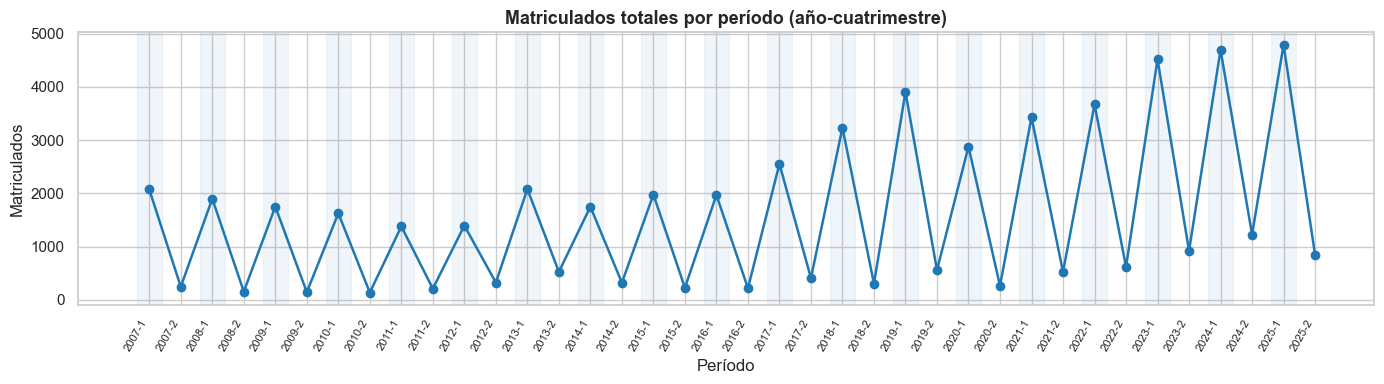

In [18]:
# Serie temporal total: evolución de matriculados por período (año-cuatrimestre)
series_total = (
    df_total_t.groupby(["time_order", "period_label"], as_index=False)[target_total]
    .sum()
    .sort_values("time_order")
)

print(f"Períodos disponibles: {len(series_total)}")
print(f"Rango temporal: {series_total['period_label'].iloc[0]} → {series_total['period_label'].iloc[-1]}")
print(f"\nEstadísticas descriptivas de '{target_total}':")
display(series_total[[target_total]].describe().T)
print("\nÚltimos 10 períodos:")
display(series_total[["period_label", target_total]].tail(10))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(series_total["period_label"], series_total[target_total], marker="o", linewidth=1.8, color="#1f77b4")

# Resaltar el cuatrimestre 1 con fondo suave para destacar la estacionalidad
for _, row in series_total.iterrows():
    if str(row["period_label"]).endswith("-1"):
        ax.axvspan(row.name - 0.4, row.name + 0.4, alpha=0.08, color="steelblue")

ax.set_title("Matriculados totales por período (año-cuatrimestre)", fontsize=13, fontweight="bold")
ax.set_xlabel("Período")
ax.set_ylabel("Matriculados")
ax.set_xticks(range(len(series_total)))
ax.set_xticklabels(series_total["period_label"], rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Análisis de estacionalidad

### 3.1 Distribución por cuatrimestre

La inscripción universitaria tiene un patrón estacional conocido: el primer cuatrimestre concentra la mayor parte de los nuevos ingresantes, mientras que el segundo cuatrimestre suele tener un volumen significativamente menor.

Esta diferencia es un componente estacional fuerte que los modelos de series de tiempo deben capturar correctamente. Si el modelo no incorpora esta estacionalidad, las predicciones del segundo cuatrimestre quedarán sobreestimadas y las del primero subestimadas.

El gráfico a continuación muestra la **distribución acumulada** de matriculados por cuatrimestre a lo largo de toda la historia disponible (2007–2025).

,cuatrimestre,aspirantes_total
0,1,51603
1,2,8175


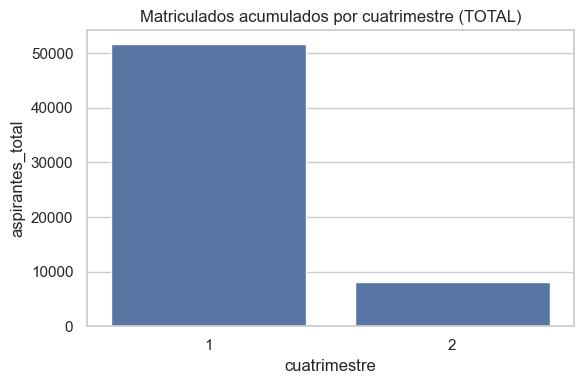

In [19]:
# Descripcion:
# Esta celda analiza la distribucion de matriculados por cuatrimestre
# en la vista total para detectar posibles efectos estacionales.
# Distribucion por cuatrimestre en TOTAL (si existe columna de cuatrimestre)
if tcol_total is not None:
    agg_term = (
        df_total_t.groupby(tcol_total, as_index=False)[target_total]
        .sum()
        .sort_values(tcol_total)
    )
    display(agg_term)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=agg_term, x=tcol_total, y=target_total)
    plt.title("Matriculados acumulados por cuatrimestre (TOTAL)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay columna de cuatrimestre en la vista total.")

## 4. Análisis por carrera

### 4.1 Volumen histórico por carrera

Identificar las carreras con mayor cantidad de matriculados acumulados es relevante por dos razones:

1. **Selección de series para modelado**: las carreras con mayor volumen histórico suelen tener series más completas y estables, lo que las hace más aptas para modelos supervisados.
2. **Priorización operativa**: desde la perspectiva de la institución, predecir con precisión las carreras de mayor demanda tiene mayor impacto en la planificación de recursos docentes y aulas.

El gráfico de evolución temporal permite observar si las carreras crecen, se estabilizan o muestran discontinuidades (por ejemplo, carreras que se abren o se discontinúan en determinados años).

In [11]:
# Descripcion:
# Esta celda construye un resumen ejecutivo del EDA
# (snapshots usados, volumen, targets y cardinalidad de carreras)
# para dejar trazabilidad hacia la etapa de modelado.
# Salida de apoyo para modelado
summary = {
    "snapshot_total": key_total,
    "snapshot_carrera": key_carrera,
    "rows_total": int(df_total.shape[0]),
    "rows_carrera": int(df_carrera.shape[0]),
    "target_total": target_total,
    "target_carrera": target_carrera,
    "n_carreras": int(df_carrera_t[career_col].nunique()),
    "horizonte_total_puntos": int(series_total.shape[0]),
}

pd.DataFrame([summary])

,snapshot_total,snapshot_carrera,rows_total,rows_carrera,target_total,target_carrera,n_carreras,horizonte_total_puntos
0,mysql_exports/unsta/vw_dm_matricula_total/snap...,mysql_exports/unsta/vw_dm_matricula_carrera/sn...,38,1011,aspirantes_total,matriculados_carrera,103,38


## 6. ¿Son suficientes los datos para predecir matrícula por carrera?

Esta es una pregunta clave antes de diseñar los modelos. Para responderla se evalúan tres dimensiones:

### 6.1 Longitud de la serie por carrera

Para que un modelo de series de tiempo produzca predicciones confiables se necesita un mínimo de observaciones. El criterio adoptado es:

| Observaciones disponibles | Capacidad de modelado |
|---|---|
| ≥ 10 períodos | **Apta para modelado** — suficiente para estimar tendencia y estacionalidad |
| 6–9 períodos | **Modelado limitado** — baseline naive o regresión simple; sin series de tiempo avanzadas |
| < 6 períodos | **No modelable de forma autónoma** — requiere datos adicionales o agrupación |

> Un período equivale a un cuatrimestre (hay dos por año). Con datos desde 2007, el máximo posible es ~36 períodos. Carreras que comenzaron a registrar matriculados más tarde tendrán series más cortas.

### 6.2 Discontinuidades en la serie

Una carrera puede tener muchos registros pero con años en cero (sin matriculados) o directamente sin registros para ciertos períodos. Esto genera **series con huecos** que dificultan el modelado.

### 6.3 Necesidad de datos externos

Si la serie propia de una carrera es insuficiente, existen dos alternativas:
1. **Agrupación**: combinar carreras afines en una macro-serie (ej. por área de conocimiento).
2. **Datos externos**: incorporar variables contextuales como egresados de nivel medio de la provincia, índice de desempleo, o datos de otras universidades de la región.

La siguiente celda cuantifica la distribución de longitud de serie por carrera para tomar la decisión de qué estrategia aplicar.

=== Distribución de carreras por capacidad de modelado ===


,estado,n_carreras,pct
0,Apta,43,41.7
1,Insuficiente,41,39.8
2,Limitada,19,18.4



=== Top 10 carreras con más períodos ===


,id_carrera,n_periodos,estado_modelado
5,12,25,Apta
2,07,24,Apta
1,04,24,Apta
6,13,24,Apta
4,11,24,Apta
14,31,24,Apta
7,14,24,Apta
22,65,24,Apta
38,94,24,Apta
20,49,23,Apta



=== Top 10 carreras con menos períodos ===


,id_carrera,n_periodos,estado_modelado
51,A9,1,Insuficiente
87,H3,1,Insuficiente
94,I4,1,Insuficiente
93,I1,1,Insuficiente
92,H9,1,Insuficiente
96,I6,1,Insuficiente
98,I9,1,Insuficiente
97,I7,1,Insuficiente
100,J2,1,Insuficiente
99,J1,1,Insuficiente


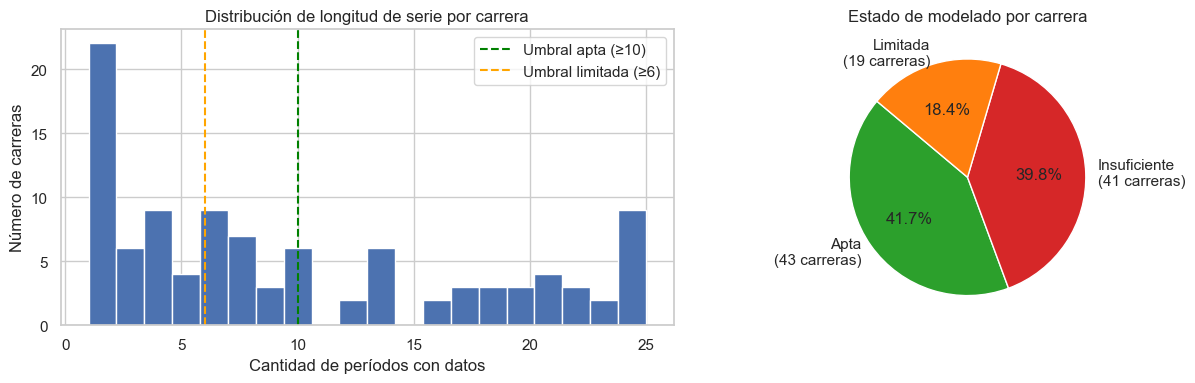


=== Completitud de series (sobre 27 períodos posibles) ===
count    103.000000
mean      36.348544
std       29.381036
min        3.700000
25%       11.100000
50%       25.900000
75%       63.000000
max       92.600000


In [22]:
# career_col ya definido en celdas anteriores

# --- 6.1 Longitud de serie por carrera ---
obs_por_carrera = (
    df_carrera_t.groupby(career_col)["time_order"]
    .nunique()
    .reset_index()
    .rename(columns={"time_order": "n_periodos"})
    .sort_values("n_periodos", ascending=False)
)

obs_por_carrera["etiqueta"] = obs_por_carrera[career_col].map(carrera_etiquetas).fillna(obs_por_carrera[career_col].astype(str))

UMBRAL_APTA    = 10
UMBRAL_LIMITADA = 6

obs_por_carrera["estado_modelado"] = obs_por_carrera["n_periodos"].apply(
    lambda n: "Apta" if n >= UMBRAL_APTA else ("Limitada" if n >= UMBRAL_LIMITADA else "Insuficiente")
)

resumen_estado = obs_por_carrera["estado_modelado"].value_counts().rename_axis("estado").reset_index(name="n_carreras")
resumen_estado["pct"] = (resumen_estado["n_carreras"] / resumen_estado["n_carreras"].sum() * 100).round(1)

print("=== Distribución de carreras por capacidad de modelado ===")
display(resumen_estado)

print(f"\n=== Top 10 carreras con más períodos ===")
display(obs_por_carrera[["etiqueta", "n_periodos", "estado_modelado"]].head(10))

print(f"\n=== Top 10 carreras con menos períodos ===")
display(obs_por_carrera[["etiqueta", "n_periodos", "estado_modelado"]].tail(10))

# --- Gráfico de distribución ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de longitud de serie
axes[0].hist(obs_por_carrera["n_periodos"], bins=20, color="#4c72b0", edgecolor="white")
axes[0].axvline(UMBRAL_APTA, color="green", linestyle="--", linewidth=1.5, label=f"Umbral apta (≥{UMBRAL_APTA})")
axes[0].axvline(UMBRAL_LIMITADA, color="orange", linestyle="--", linewidth=1.5, label=f"Umbral limitada (≥{UMBRAL_LIMITADA})")
axes[0].set_title("Distribución de longitud de serie por carrera")
axes[0].set_xlabel("Cantidad de períodos con datos")
axes[0].set_ylabel("Número de carreras")
axes[0].legend()

# Gráfico de torta con estados
colors = {"Apta": "#2ca02c", "Limitada": "#ff7f0e", "Insuficiente": "#d62728"}
pie_data = resumen_estado.set_index("estado")["n_carreras"]
axes[1].pie(
    pie_data,
    labels=[f"{k}\n({v} carreras)" for k, v in pie_data.items()],
    colors=[colors.get(k, "gray") for k in pie_data.index],
    autopct="%1.1f%%",
    startangle=140,
)
axes[1].set_title("Estado de modelado por carrera")

plt.tight_layout()
plt.show()

# --- 6.2 Discontinuidades: períodos sin datos por carrera ---
total_periodos_posibles = df_carrera_t["time_order"].nunique()
completitud = obs_por_carrera.copy()
completitud["completitud_pct"] = (completitud["n_periodos"] / total_periodos_posibles * 100).round(1)

print(f"\n=== Completitud de series (sobre {total_periodos_posibles} períodos posibles) ===")
print(completitud["completitud_pct"].describe().to_string())

### 6.4 Conclusión: ¿se pueden predecir las matrículas por carrera con los datos actuales?

**Respuesta corta: sí, con estrategia diferenciada según la carrera.**

La tabla anterior permite segmentar las carreras en tres grupos de estrategia de modelado:

| Grupo | Criterio | Estrategia recomendada |
|---|---|---|
| **Aptas** (≥ 10 períodos) | Serie suficiente | Modelos de series de tiempo: SARIMA, Prophet, ETS. Se puede aplicar validación walk-forward. |
| **Limitadas** (6–9 períodos) | Serie corta pero usable | Modelos baseline (naive estacional, promedio móvil). Evaluar si agregar datos externos mejora la performance. |
| **Insuficientes** (< 6 períodos) | Serie demasiado corta | No modelar individualmente. Opciones: (a) agrupar con carreras afines, (b) predecir como proporción del total universidad, (c) excluir del alcance del proyecto. |

**¿Se necesitan datos externos?**

Para las carreras **aptas**, los datos propios son suficientes en esta primera versión del modelo. Para las carreras **limitadas e insuficientes**, incorporar variables contextuales podría mejorar la predicción:

- Egresados de nivel medio de la provincia (proxy de demanda potencial).
- Inscriptos en otras universidades de la región (efecto de competencia).
- Variables macroeconómicas: desempleo, PBI, costo arancelario.
- Datos de difusión: inscriptos a jornadas de orientación vocacional de la UNSTA.

Para el **alcance del proyecto final**, se propone trabajar únicamente con las carreras **aptas**, dejando las demás estrategias como trabajo futuro documentado.